In [2]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt

LOAD TRAINED MODEL

In [3]:
model = tf.keras.models.load_model("model/best_brain_tumor_model.h5")

# class names
classes = ["glioma","meningioma","pituitary","no_tumor"]

IMG_SIZE = 224

IMAGE PATH

In [ ]:
img_path = r"C:\Users\User\OneDrive - NSBM\Desktop\Final Project\ML\testing_images_class\glioma\brisc2025_train_00007_gl_ax_t1.jpg"

LOAD IMAGE

In [5]:
img = cv2.imread(img_path)
orig_img = img.copy()

PREPROCESS IMAGE

In [6]:
img_resized = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
img_norm = img_resized / 255.0
img_array = np.expand_dims(img_norm,axis=0)

MODEL PREDICTION

In [7]:
pred = model.predict(img_array)

class_id = np.argmax(pred)
predicted_class = classes[class_id]

confidence = float(np.max(pred)) * 100

1/1 [==============================] - 1s 1s/step


ADD TEXT TO IMAGE

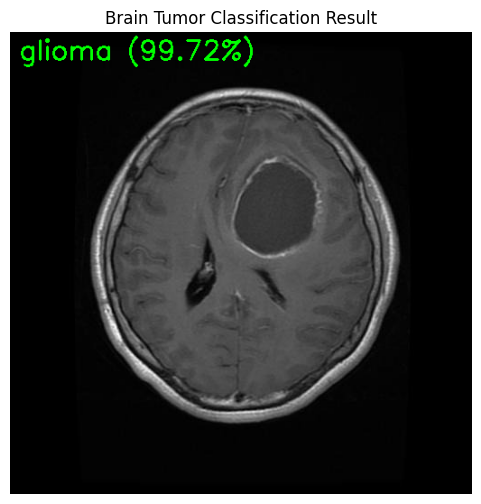

Predicted Class: glioma
Confidence: 99.71808195114136 %


In [8]:
label = f"{predicted_class} ({confidence:.2f}%)"

cv2.putText(
    orig_img,
    label,
    (10,30),
    cv2.FONT_HERSHEY_SIMPLEX,
    1,
    (0,255,0),
    2
)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(orig_img,cv2.COLOR_BGR2RGB))
plt.title("Brain Tumor Classification Result")
plt.axis("off")
plt.show()

print("Predicted Class:", predicted_class)
print("Confidence:", confidence, "%")